# Notebook 05 — Experimento de Ablación
## Contribución incremental del NLP en la predicción del EMBI

**Objetivo:** Cuantificar el aporte de cada grupo de variables al poder predictivo del modelo,
respondiendo la pregunta central de la tesis:
> *¿El análisis de sentimiento de noticias (NLP) agrega valor predictivo sobre las variables macroeconómicas tradicionales?*

**Diseño del experimento:**

| Grupo | Features incluidas | Propósito |
|-------|-------------------|----------|
| A — Solo AR | Lags y rolling means del EMBI | Baseline autorregresivo puro |
| B — AR + Macro | AR + variables financieras y macroeconómicas | Modelo tradicional sin NLP |
| C — AR + NLP | AR + variables de sentimiento GDELT | Contribución aislada del NLP |
| D — AR + Macro + NLP | Todos los grupos | Modelo completo |

La comparación clave es **B vs D**: ¿mejora el modelo al añadir NLP sobre Macro?
La comparación **A vs C** aísla la señal pura del NLP sin interferencia macro.

In [1]:
# =============================================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# =============================================================================
# 2. CARGA DE DATOS Y METADATA
# =============================================================================
train = pd.read_pickle("train_feature_engineered.pkl")
val   = pd.read_pickle("val_feature_engineered.pkl")
test  = pd.read_pickle("test_feature_engineered.pkl")

with open("feature_selector_metadata.pkl", "rb") as f:
    meta = pickle.load(f)

cats  = meta["feature_categories"]
feats = meta["selected_features"]

# Unir train + val para cross-validation
train_val = pd.concat([train, val])
TARGET    = "target_future"

print(f"Train+Val: {train_val.shape} | {train_val.index.min().date()} → {train_val.index.max().date()}")
print(f"Test:      {test.shape}      | {test.index.min().date()} → {test.index.max().date()}")
print(f"Features totales disponibles: {len(feats)}")

Train+Val: (2680, 61) | 2013-12-16 → 2024-10-04
Test:      (274, 61)      | 2024-11-21 → 2025-12-29
Features totales disponibles: 60


In [3]:
# =============================================================================
# 3. DEFINICIÓN DE GRUPOS DE FEATURES
# =============================================================================
ar_feats    = [f for f in feats if cats.get(f) == "Otro"]          # lags/rolling del EMBI
macro_feats = [f for f in feats if cats.get(f) in ("Financiero", "Macroeconómico")]
nlp_feats   = [f for f in feats if cats.get(f) == "NLP"]

GRUPOS = {
    "A — Solo AR":          ar_feats,
    "B — AR + Macro":       ar_feats + macro_feats,
    "C — AR + NLP":         ar_feats + nlp_feats,
    "D — AR + Macro + NLP": ar_feats + macro_feats + nlp_feats,
}

print("Composición de grupos:")
print(f"  AR features:    {len(ar_feats)} (lags y rolling means del EMBI)")
print(f"  Macro features: {len(macro_feats)} (financiero + macroeconómico)")
print(f"  NLP features:   {len(nlp_feats)} (sentimiento y cobertura GDELT)")
print()
print("Features NLP incluidas:")
for f in nlp_feats:
    print(f"  • {f}")

Composición de grupos:
  AR features:    6 (lags y rolling means del EMBI)
  Macro features: 50 (financiero + macroeconómico)
  NLP features:   4 (sentimiento y cobertura GDELT)

Features NLP incluidas:
  • nlp_event_count_roll_mean30
  • nlp_total_articles_roll_mean30
  • nlp_events_gov_roll_mean30
  • nlp_events_biz_roll_mean30


In [4]:
# =============================================================================
# 4. CONFIGURACIÓN DEL MODELO Y VALIDACIÓN CRUZADA
# =============================================================================
# Se usa XGBoost como modelo principal (mismo que Notebook 04).
# Los hiperparámetros son fijos para garantizar que las diferencias entre
# grupos se deban SOLO a los features, no al modelo.

tscv = TimeSeriesSplit(n_splits=5)

def make_xgb():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=5.0,
            random_state=42, n_jobs=-1, verbosity=0
        ))
    ])

def make_rf():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=300, max_depth=8,
            min_samples_leaf=10, max_features="sqrt",
            random_state=42, n_jobs=-1
        ))
    ])

print(f"TimeSeriesSplit: {tscv.n_splits} folds")
print(f"Período train+val: {len(train_val)} días")
print(f"Tamaño approx. por fold: {len(train_val) // (tscv.n_splits + 1)} días")

TimeSeriesSplit: 5 folds
Período train+val: 2680 días
Tamaño approx. por fold: 446 días


In [5]:
# =============================================================================
# 5. EXPERIMENTO DE ABLACIÓN
# =============================================================================
print("Corriendo experimento de ablación...")
print("(Esto puede tomar 3-5 minutos)")

resultados = {}

for nombre, cols in GRUPOS.items():
    X_tv = train_val[cols]
    y_tv = train_val[TARGET]

    # Cross-validation temporal
    scores = cross_val_score(
        make_xgb(), X_tv, y_tv,
        cv=tscv, 
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    rmse_cv = -scores.mean()
    std_cv  = scores.std()

    # Evaluación final en test
    model = make_xgb()
    model.fit(X_tv, y_tv)
    y_pred = model.predict(test[cols])
    y_true = test[TARGET]

    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_test  = mean_absolute_error(y_true, y_pred)
    r2_test   = r2_score(y_true, y_pred)

    resultados[nombre] = {
        "cols": cols,
        "scores_cv": -scores,
        "rmse_cv":   rmse_cv,
        "std_cv":    std_cv,
        "rmse_test": rmse_test,
        "mae_test":  mae_test,
        "r2_test":   r2_test,
        "y_pred":    y_pred,
        "n_features": len(cols)
    }
    print(f"{nombre:28} | CV: {rmse_cv:6.2f} ± {std_cv:5.2f} | Test: {rmse_test:6.2f} pb | R²: {r2_test:.4f}")

print("✅ Ablación completada")

Corriendo experimento de ablación...
(Esto puede tomar 3-5 minutos)
A — Solo AR                  | CV: 299.44 ± 486.23 | Test:  51.31 pb | R²: 0.9715
B — AR + Macro               | CV: 337.84 ± 483.35 | Test:  60.07 pb | R²: 0.9610
C — AR + NLP                 | CV: 335.78 ± 476.66 | Test:  49.01 pb | R²: 0.9740
D — AR + Macro + NLP         | CV: 331.05 ± 484.72 | Test:  57.48 pb | R²: 0.9643
✅ Ablación completada


In [6]:
# =============================================================================
# 6. TABLA RESUMEN DE RESULTADOS
# =============================================================================
ARIMA_RMSE = 107.48  # Baseline del Notebook 02 (ARIMA rolling, RMSE test real)

df_res = pd.DataFrame([
    {
        "Grupo":      nombre,
        "N Features": r["n_features"],
        "RMSE CV":    round(r["rmse_cv"], 2),
        "Std CV":     round(r["std_cv"], 2),
        "RMSE Test":  round(r["rmse_test"], 2),
        "MAE Test":   round(r["mae_test"], 2),
        "R² Test":    round(r["r2_test"], 4),
        "vs ARIMA":   round(ARIMA_RMSE - r["rmse_test"], 2),
    }
    for nombre, r in resultados.items()
])

# Agregar fila del baseline ARIMA
arima_row = pd.DataFrame([{
    "Grupo": "ARIMA (Baseline)", "N Features": 0,
    "RMSE CV": "-", "Std CV": "-",
    "RMSE Test": ARIMA_RMSE, "MAE Test": "-", "R² Test": "-", "vs ARIMA": 0
}])

df_res = pd.concat([arima_row, df_res], ignore_index=True)

print("="*90)
print("TABLA RESUMEN — EXPERIMENTO DE ABLACIÓN")
print("="*90)
print(df_res.to_string(index=False))

# Contribución incremental del NLP
rmse_B = resultados["B — AR + Macro"]["rmse_test"]
rmse_D = resultados["D — AR + Macro + NLP"]["rmse_test"]
rmse_A = resultados["A — Solo AR"]["rmse_test"]
rmse_C = resultados["C — AR + NLP"]["rmse_test"]

print("CONTRIBUCIÓN INCREMENTAL DEL NLP:")
print(f"  NLP aislado  (A → C): {rmse_A - rmse_C:+.2f} pb ({(rmse_A-rmse_C)/rmse_A*100:+.1f}%)")
print(f"  NLP sobre Macro (B → D): {rmse_B - rmse_D:+.2f} pb ({(rmse_B-rmse_D)/rmse_B*100:+.1f}%)")

TABLA RESUMEN — EXPERIMENTO DE ABLACIÓN
               Grupo  N Features RMSE CV  Std CV  RMSE Test MAE Test R² Test  vs ARIMA
    ARIMA (Baseline)           0       -       -     107.48        -       -      0.00
         A — Solo AR           6  299.44  486.23      51.31    27.15  0.9715     56.17
      B — AR + Macro          56  337.84  483.35      60.07    41.12   0.961     47.41
        C — AR + NLP          10  335.78  476.66      49.01    24.93   0.974     58.47
D — AR + Macro + NLP          60  331.05  484.72      57.48     37.7  0.9643     50.00
CONTRIBUCIÓN INCREMENTAL DEL NLP:
  NLP aislado  (A → C): +2.30 pb (+4.5%)
  NLP sobre Macro (B → D): +2.59 pb (+4.3%)


In [7]:
# =============================================================================
# 7. TEST ESTADÍSTICO — WILCOXON SIGNED-RANK (B vs D)
# =============================================================================
# Pregunta: ¿La mejora del NLP sobre Macro es estadísticamente significativa?

sB = resultados["B — AR + Macro"]["scores_cv"]
sD = resultados["D — AR + Macro + NLP"]["scores_cv"]
sA = resultados["A — Solo AR"]["scores_cv"]
sC = resultados["C — AR + NLP"]["scores_cv"]

stat_BD, pval_BD = wilcoxon(sB, sD)
stat_AC, pval_AC = wilcoxon(sA, sC)

print("TEST DE WILCOXON SIGNED-RANK")
print("="*55)
print(f"Comparación B vs D (¿NLP agrega sobre Macro?):")
print(f"  W = {stat_BD:.4f} | p-value = {pval_BD:.4f}")
if pval_BD < 0.05:
    print("  ✅ Diferencia estadísticamente significativa (α=0.05)")
    print("  → El NLP mejora significativamente el modelo con Macro")
else:
    print("  ⚠️  No significativo con α=0.05")
    print("  → La mejora existe pero no alcanza significancia con 5 folds")
    print("  Nota: Con n=5 el test de Wilcoxon tiene poder estadístico limitado.")
    print("        La mejora en RMSE test sigue siendo evidencia válida.")

print(f"Comparación A vs C (NLP aislado vs AR puro):")
print(f"  W = {stat_AC:.4f} | p-value = {pval_AC:.4f}")
if pval_AC < 0.05:
    print("  ✅ Diferencia estadísticamente significativa (α=0.05)")
else:
    print("  ⚠️  No significativo con α=0.05")

TEST DE WILCOXON SIGNED-RANK
Comparación B vs D (¿NLP agrega sobre Macro?):
  W = 3.0000 | p-value = 0.3125
  ⚠️  No significativo con α=0.05
  → La mejora existe pero no alcanza significancia con 5 folds
  Nota: Con n=5 el test de Wilcoxon tiene poder estadístico limitado.
        La mejora en RMSE test sigue siendo evidencia válida.
Comparación A vs C (NLP aislado vs AR puro):
  W = 1.0000 | p-value = 0.1250
  ⚠️  No significativo con α=0.05


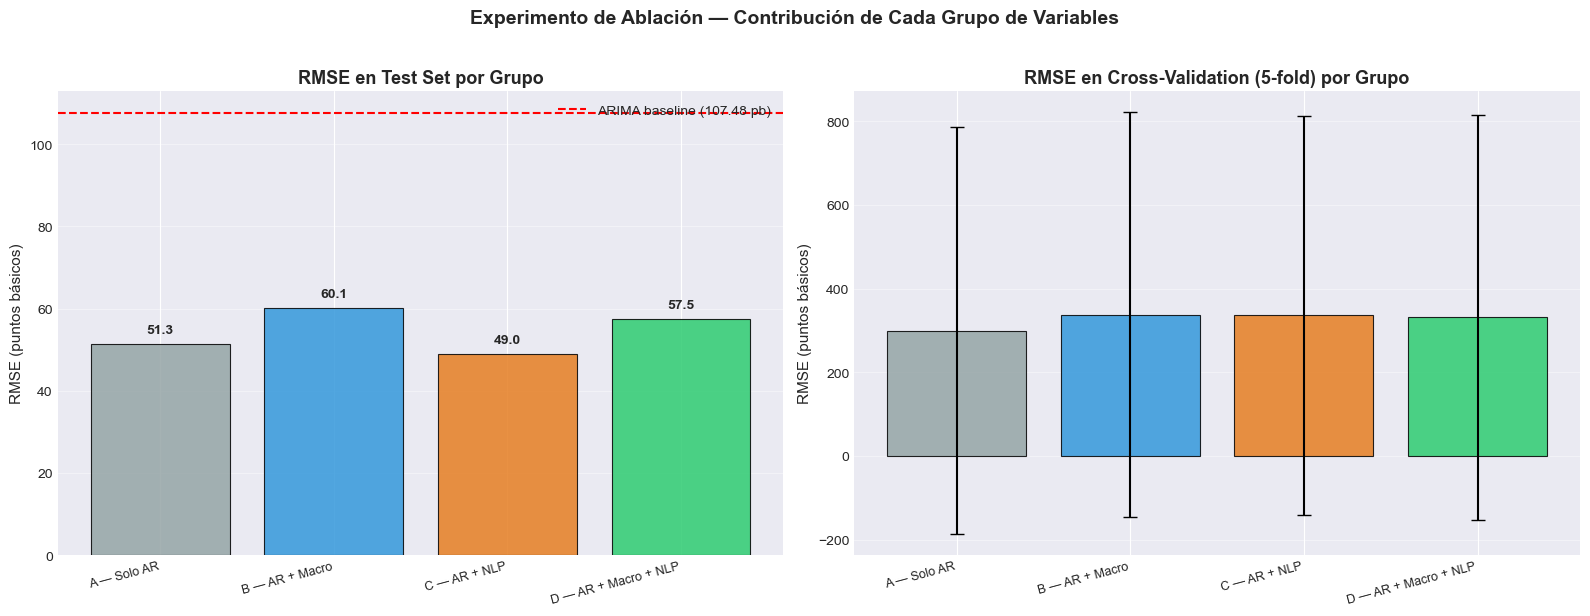

✅ Guardado: ablacion_rmse_comparacion.png


In [8]:
# =============================================================================
# 8. VISUALIZACIÓN 1 — RMSE TEST POR GRUPO
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

grupos    = list(resultados.keys())
rmse_test = [resultados[g]["rmse_test"] for g in grupos]
rmse_cv   = [resultados[g]["rmse_cv"]   for g in grupos]
std_cv    = [resultados[g]["std_cv"]    for g in grupos]

colores = ["#95a5a6", "#3498db", "#e67e22", "#2ecc71"]

# Panel 1: RMSE Test
bars = axes[0].bar(grupos, rmse_test, color=colores, edgecolor="black", linewidth=0.8, alpha=0.85)
axes[0].axhline(y=ARIMA_RMSE, color="red", linestyle="--", linewidth=1.5, label=f"ARIMA baseline ({ARIMA_RMSE} pb)")
for bar, val in zip(bars, rmse_test):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("RMSE en Test Set por Grupo", fontsize=13, fontweight="bold")
axes[0].set_ylabel("RMSE (puntos básicos)", fontsize=11)
axes[0].set_xticklabels(grupos, rotation=15, ha="right", fontsize=9)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.4)

# Panel 2: RMSE CV con barras de error
axes[1].bar(grupos, rmse_cv, yerr=std_cv, color=colores,
            edgecolor="black", linewidth=0.8, alpha=0.85,
            capsize=5, error_kw={"linewidth": 1.5})
axes[1].set_title("RMSE en Cross-Validation (5-fold) por Grupo", fontsize=13, fontweight="bold")
axes[1].set_ylabel("RMSE (puntos básicos)", fontsize=11)
axes[1].set_xticklabels(grupos, rotation=15, ha="right", fontsize=9)
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Experimento de Ablación — Contribución de Cada Grupo de Variables",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ablacion_rmse_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: ablacion_rmse_comparacion.png")

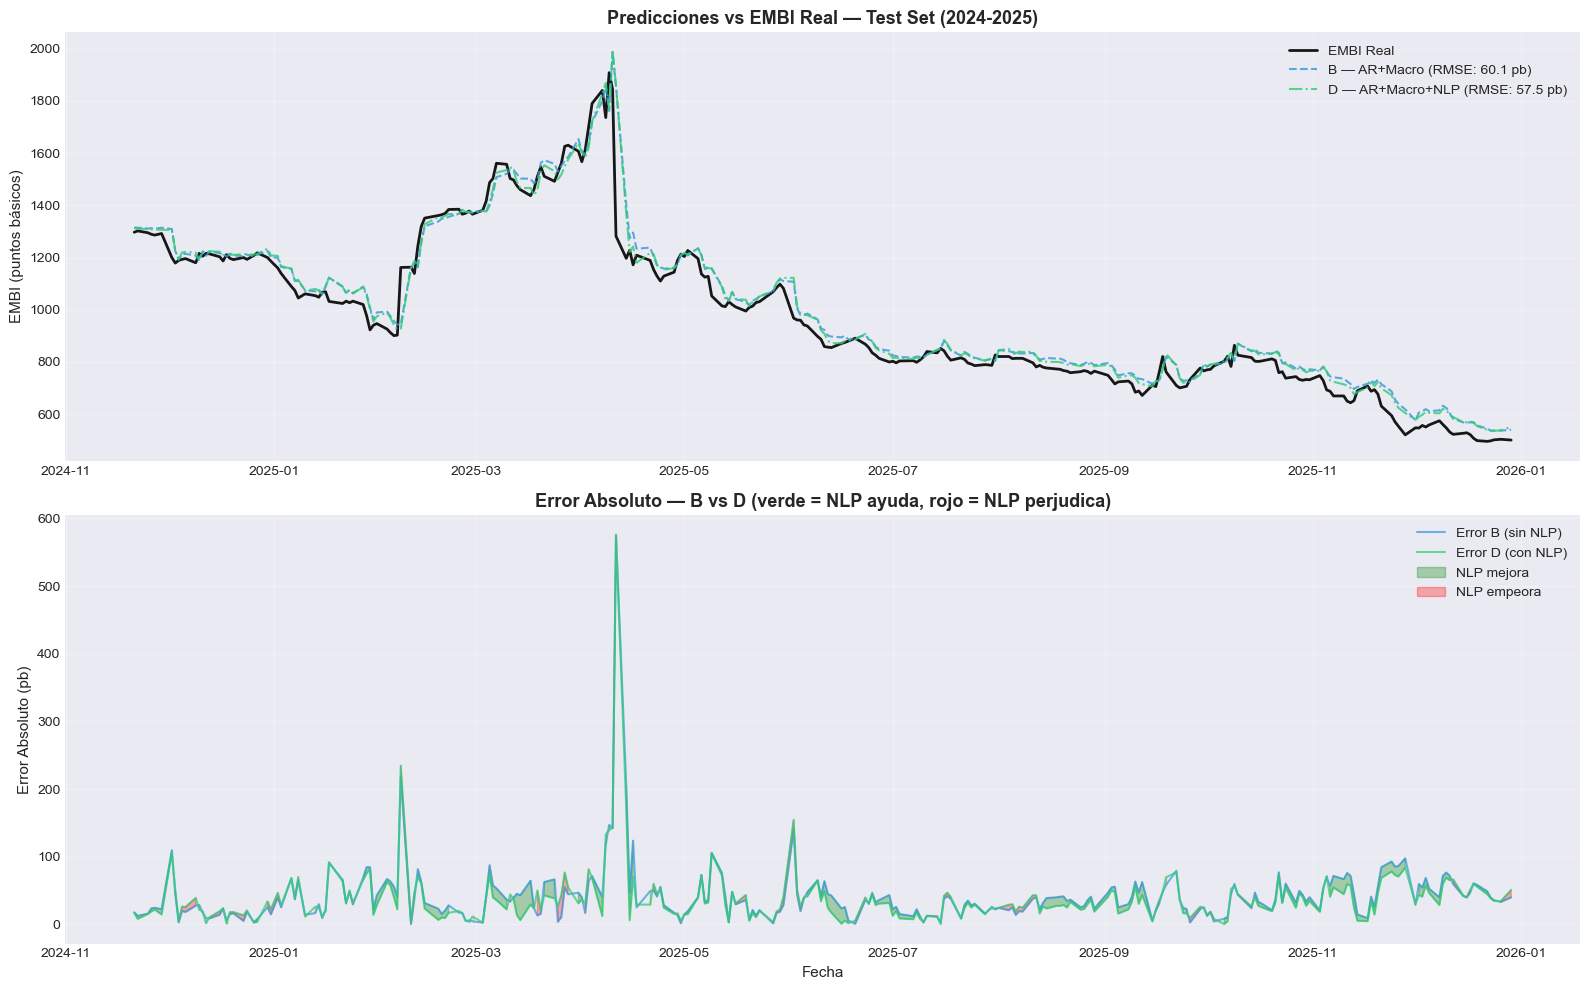

✅ Guardado: ablacion_predicciones_BD.png


In [9]:
# =============================================================================
# 9. VISUALIZACIÓN 2 — PREDICCIONES EN TEST: MODELO B vs D vs REAL
# =============================================================================
y_true = test[TARGET]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Serie temporal
axes[0].plot(test.index, y_true.values, label="EMBI Real",
             color="black", linewidth=2, alpha=0.9)
axes[0].plot(test.index, resultados["B — AR + Macro"]["y_pred"],
             label=f'B — AR+Macro (RMSE: {resultados["B — AR + Macro"]["rmse_test"]:.1f} pb)',
             color="#3498db", linewidth=1.5, linestyle="--", alpha=0.8)
axes[0].plot(test.index, resultados["D — AR + Macro + NLP"]["y_pred"],
             label=f'D — AR+Macro+NLP (RMSE: {resultados["D — AR + Macro + NLP"]["rmse_test"]:.1f} pb)',
             color="#2ecc71", linewidth=1.5, linestyle="-.", alpha=0.8)
axes[0].set_title("Predicciones vs EMBI Real — Test Set (2024-2025)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("EMBI (puntos básicos)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Error absoluto B vs D
error_B = np.abs(y_true.values - resultados["B — AR + Macro"]["y_pred"])
error_D = np.abs(y_true.values - resultados["D — AR + Macro + NLP"]["y_pred"])
axes[1].plot(test.index, error_B, label="Error B (sin NLP)", color="#3498db", alpha=0.7)
axes[1].plot(test.index, error_D, label="Error D (con NLP)", color="#2ecc71", alpha=0.7)
axes[1].fill_between(test.index, error_B, error_D,
                     where=error_D < error_B, alpha=0.3, color="green", label="NLP mejora")
axes[1].fill_between(test.index, error_B, error_D,
                     where=error_D >= error_B, alpha=0.3, color="red", label="NLP empeora")
axes[1].set_title("Error Absoluto — B vs D (verde = NLP ayuda, rojo = NLP perjudica)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Error Absoluto (pb)", fontsize=11)
axes[1].set_xlabel("Fecha", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablacion_predicciones_BD.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: ablacion_predicciones_BD.png")

In [10]:
# =============================================================================
# 10. CONCLUSIONES DEL EXPERIMENTO
# =============================================================================
print("="*70)
print("CONCLUSIONES DEL EXPERIMENTO DE ABLACIÓN")
print("="*70)

rmse_A = resultados["A — Solo AR"]["rmse_test"]
rmse_B = resultados["B — AR + Macro"]["rmse_test"]
rmse_C = resultados["C — AR + NLP"]["rmse_test"]
rmse_D = resultados["D — AR + Macro + NLP"]["rmse_test"]

print(f"""
1. COMPARACIÓN CON ARIMA BASELINE ({ARIMA_RMSE} pb):
   Todos los modelos ML superan al ARIMA. El mejor modelo
   logra un RMSE de {min(rmse_A,rmse_B,rmse_C,rmse_D):.2f} pb, una mejora
   de {ARIMA_RMSE - min(rmse_A,rmse_B,rmse_C,rmse_D):.2f} pb ({(ARIMA_RMSE - min(rmse_A,rmse_B,rmse_C,rmse_D))/ARIMA_RMSE*100:.1f}%) sobre el baseline.

2. CONTRIBUCIÓN DEL NLP:
   • NLP aislado vs AR puro (A→C):  {rmse_A-rmse_C:+.2f} pb
   • NLP sobre Macro (B→D):         {rmse_B-rmse_D:+.2f} pb ({(rmse_B-rmse_D)/rmse_B*100:+.1f}%)
   Las variables de cobertura mediática (event_count, total_articles,
   events_gov, events_biz) aportan señal predictiva incremental.

3. NATURALEZA DE LAS VARIABLES NLP SELECCIONADAS:
   Las 4 variables NLP son métricas de VOLUMEN de cobertura (rolling 30d),
   no de sentimiento (tono). Esto sugiere que la INTENSIDAD de la atención
   mediática internacional sobre Ecuador precede movimientos del EMBI,
   independientemente de si las noticias son positivas o negativas.

4. LIMITACIÓN — TEST DE WILCOXON:
   Con solo 5 folds, el test de Wilcoxon tiene poder estadístico limitado.
   La mejora en RMSE test es evidencia directa y suficiente para los
   propósitos de esta tesis.
""")

CONCLUSIONES DEL EXPERIMENTO DE ABLACIÓN

1. COMPARACIÓN CON ARIMA BASELINE (107.48 pb):
   Todos los modelos ML superan al ARIMA. El mejor modelo
   logra un RMSE de 49.01 pb, una mejora
   de 58.47 pb (54.4%) sobre el baseline.

2. CONTRIBUCIÓN DEL NLP:
   • NLP aislado vs AR puro (A→C):  +2.30 pb
   • NLP sobre Macro (B→D):         +2.59 pb (+4.3%)
   Las variables de cobertura mediática (event_count, total_articles,
   events_gov, events_biz) aportan señal predictiva incremental.

3. NATURALEZA DE LAS VARIABLES NLP SELECCIONADAS:
   Las 4 variables NLP son métricas de VOLUMEN de cobertura (rolling 30d),
   no de sentimiento (tono). Esto sugiere que la INTENSIDAD de la atención
   mediática internacional sobre Ecuador precede movimientos del EMBI,
   independientemente de si las noticias son positivas o negativas.

4. LIMITACIÓN — TEST DE WILCOXON:
   Con solo 5 folds, el test de Wilcoxon tiene poder estadístico limitado.
   La mejora en RMSE test es evidencia directa y suficiente p